<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/notebooks/02_model_traning_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
%pip install scikit-learn

In [4]:
!pip install kaggle

In [5]:
import kagglehub

path = kagglehub.dataset_download("ganeshmohane/indian-emergency-vehicles-dataset")

print("Path to dataset files:", path)


100%|██████████| 195M/195M [00:03<00:00, 67.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ganeshmohane/indian-emergency-vehicles-dataset/versions/1


In [6]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/ganeshmohane/indian-emergency-vehicles-dataset/versions/1"

os.listdir(dataset_path)

['test', 'train', 'valid', 'README.roboflow.txt']

In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00


In [8]:
train = pd.read_csv(dataset_path + "/train/_classes.csv")
valid = pd.read_csv(dataset_path + "/valid/_classes.csv")
test = pd.read_csv(dataset_path + "/test/_classes.csv")

In [10]:
classes = [
    "TwoWheelers",
    "ambulance",
    "auto-rikshaw",
    "bus",
    "car",
    "firetruck",
    "police vehicle"
]
def get_label(row):
    for c in classes:
        if row[c] == 1:
            return c
    return "unknown"

train.columns = train.columns.str.strip()
valid.columns = valid.columns.str.strip()
test.columns = test.columns.str.strip()

train["label"] = train.apply(get_label, axis=1)
valid["label"] = valid.apply(get_label, axis=1)
test["label"] = test.apply(get_label, axis=1)

In [11]:
import os
import shutil

output_path = "/content/drive/MyDrive/Ai_Traffic_Flow_optimizer"

splits = ["train", "valid", "test"]

for split in splits:

    csv_path = f"{dataset_path}/{split}/_classes.csv"
    df = pd.read_csv(csv_path)

    # Clean column names again just to be safe
    df.columns = df.columns.str.strip()

    # Create class folders
    for cls in classes:
        os.makedirs(f"{output_path}/{split}/{cls}", exist_ok=True)

    for _, row in df.iterrows():

        img_name = row["filename"]
        src = os.path.join(dataset_path, split, img_name)

        for cls in classes:

            if row[cls] == 1:

                dst = os.path.join(output_path, split, cls, img_name)

                if os.path.exists(src):
                    shutil.copy(src, dst)


In [12]:
print(os.listdir("/content/drive/MyDrive/Ai_Traffic_Flow_optimizer"))

['test', 'train', 'valid']


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/drive/MyDrive/Ai_Traffic_Flow_optimizer",
    epochs=50,
    imgsz=320,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Ai_Traffic_Flow_optimizer, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1e2a361400>
curves: []
curves_results: []
fitness: 0.9252747297286987
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8505494594573975, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9252747297286987}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.3518941450578155, 'inference': 0.9198954153811888, 'loss': 0.0004662285761326899, 'postprocess': 0.0005296307730592102}
top1: 0.8505494594573975
top5: 1.0

In [14]:
import torch
print(torch.cuda.is_available())

True


In [15]:
model = YOLO("/content/runs/classify/train/weights/best.pt")


In [16]:
metrics = model.val(data="/content/drive/MyDrive/Ai_Traffic_Flow_optimizer")
print(metrics)


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,443,847 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/train... found 5923 images in 7 classes ✅ 
val: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... found 455 images in 7 classes ✅ 
test: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/test... found 344 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 755.0±535.2 MB/s, size: 18.7 KB)
val: Scanning /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... 455 images, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 212.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 12.1it/s 2.4s
                   all      0.851          1
Speed: 0.7ms preprocess, 1.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

In [17]:
print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)
print("Fitness Score:", metrics.fitness)

Top-1 Accuracy: 0.8505494594573975
Top-5 Accuracy: 1.0
Fitness Score: 0.9252747297286987


In [18]:
metrics = model.val()

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/train... found 5923 images in 7 classes ✅ 
val: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... found 455 images in 7 classes ✅ 
test: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/test... found 344 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 498.7±371.7 MB/s, size: 18.7 KB)
val: Scanning /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... 455 images, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 159.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 9.9it/s 2.9s
                   all      0.851          1
Speed: 0.7ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2


In [19]:
print(metrics.confusion_matrix)

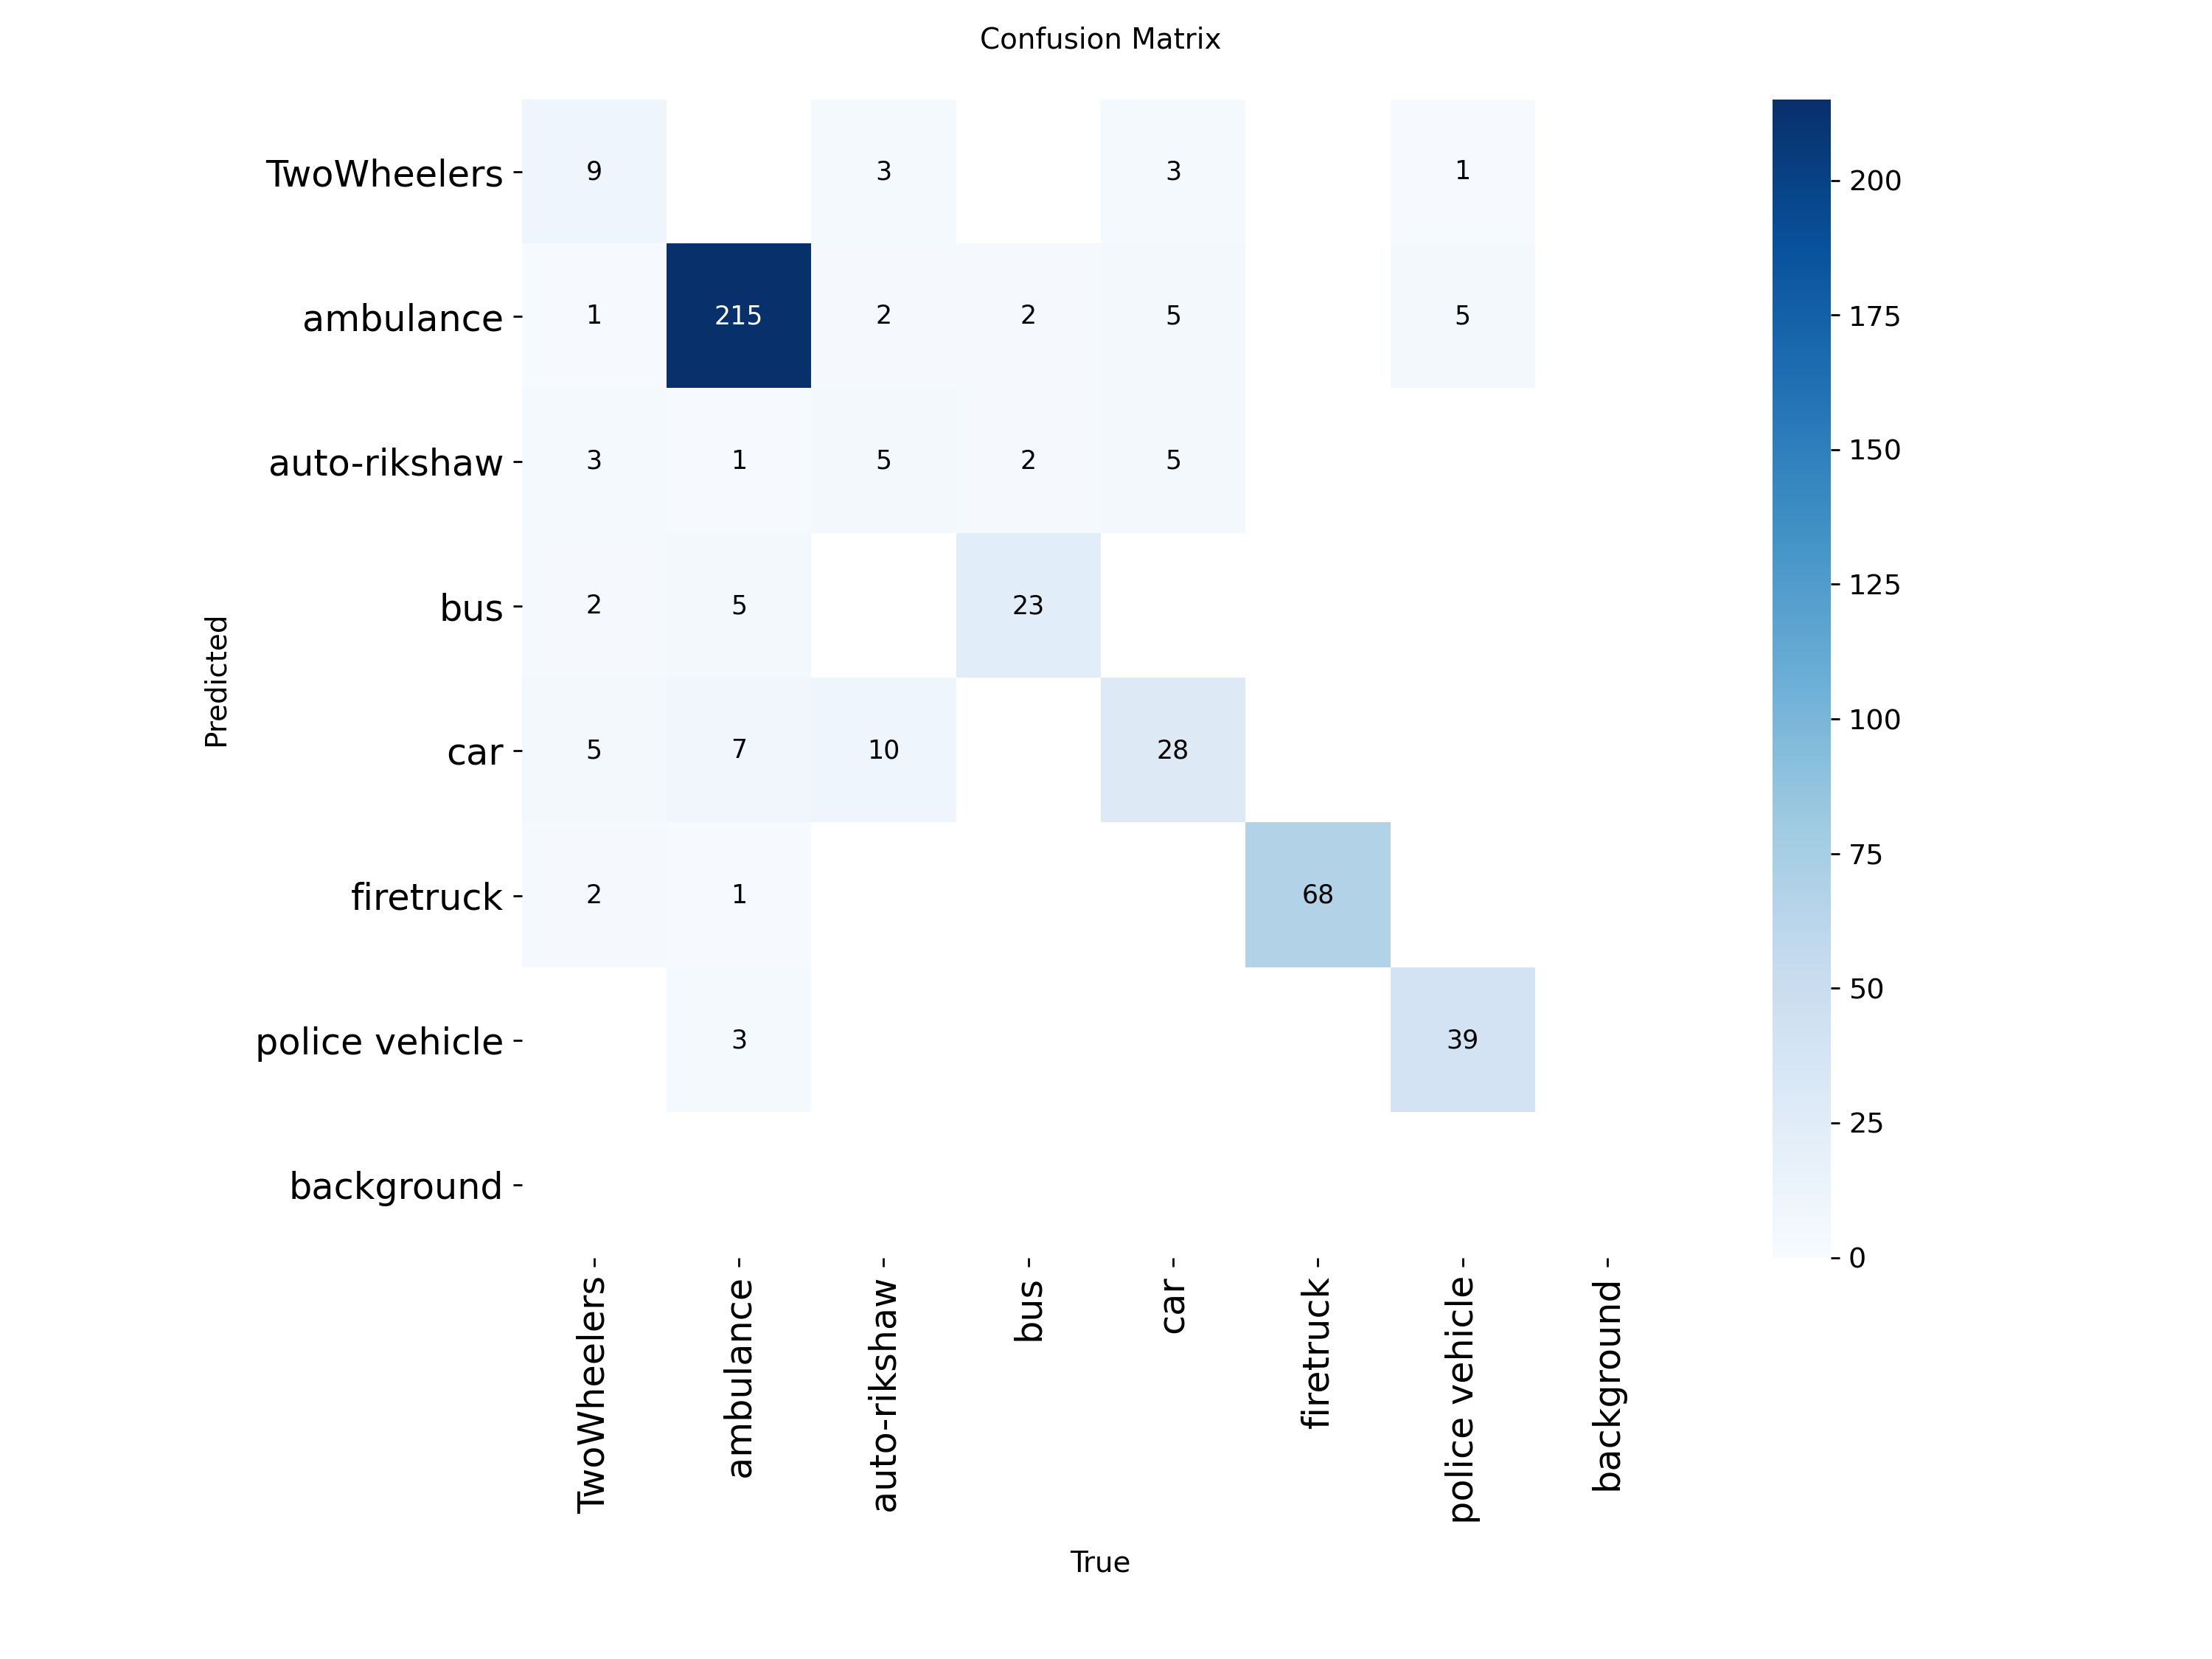

In [20]:
from IPython.display import Image
Image("/content/runs/classify/train/confusion_matrix.png")

In [21]:
metrics = model.val(data="/content/drive/MyDrive/Ai_Traffic_Flow_optimizer")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/train... found 5923 images in 7 classes ✅ 
val: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... found 455 images in 7 classes ✅ 
test: /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/test... found 344 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 453.9±241.8 MB/s, size: 18.7 KB)
val: Scanning /content/drive/MyDrive/Ai_Traffic_Flow_optimizer/valid... 455 images, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 173.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 12.0it/s 2.4s
                   all      0.851          1
Speed: 0.6ms preprocess, 1.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val3


In [ ]:
model = YOLO("/content/runs/classify/train/weights/best.pt")